## Section 1 — Setup

In [1]:
# Packages
# DBI / RMariaDB: database connection
# dplyr: data manipulation
# ggplot2: visualisation
# pwr: power analysis calculations
# effsize: Cohen's d effect size
# here: reliable path resolution regardless of working directory

suppressPackageStartupMessages({
  library(DBI)
  library(RMariaDB)
  library(dplyr)
  library(ggplot2)
  library(pwr)
  library(effsize)
  library(here)
})

# Load credentials from .env. Passwords are never hardcoded.
env_path <- here(".env")
if (!file.exists(env_path)) stop(".env file not found at project root.")
readRenviron(env_path)

cat("Setup complete.\n")

Setup complete.


In [2]:
# Database connection
# This cell is kept separate from the package setup so it can be re-run independently
# if the connection drops mid-session without disturbing the environment.
#
# Note: on.exit() is not used here. In a Jupyter notebook, on.exit() fires when the
# cell scope ends — immediately after the cell runs — which disconnects con before any
# subsequent cell can use it. Explicit teardown in the final cell is the correct pattern
# for notebooks. on.exit() belongs in production scripts, not notebooks.
#
# bigint = "integer" prevents RMariaDB returning bigint columns as character strings.

con <- dbConnect(
  RMariaDB::MariaDB(),
  host     = Sys.getenv("DB_HOST"),
  port     = as.integer(Sys.getenv("DB_PORT")),
  dbname   = Sys.getenv("DB_NAME"),
  user     = Sys.getenv("DB_USER"),
  password = Sys.getenv("DB_PASSWORD"),
  bigint   = "integer"
)

cat("Connection established.\n")

Connection established.


In [3]:
# Shared theme applied to every chart in this notebook for visual consistency.

portfolio_theme <- theme_minimal(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14, margin = margin(b = 6)),
    plot.subtitle    = element_text(size = 11, color = "#555555", margin = margin(b = 10)),
    plot.caption     = element_text(size = 9, color = "#888888", hjust = 0),
    axis.title       = element_text(size = 11),
    legend.position  = "bottom",
    panel.grid.minor = element_blank()
  )

charts_dir <- here("reports", "charts")
if (!dir.exists(charts_dir)) dir.create(charts_dir, recursive = TRUE)

cat("Theme and output directory ready.\n")

Theme and output directory ready.


## Section 2 — Power Analysis

Power analysis answers: how many observations do we need to reliably detect a meaningful effect?

This step must happen before the test, not after. Running a test and calculating power post-hoc is bad practice because you are working backwards from a result, which inflates apparent significance.

Three inputs define the calculation.

Significance level (α) is set at 0.05 — a 5% chance of a false positive is acceptable for a business pricing decision. Power (1 − β) is set at 0.80 — the statistical standard, meaning an 80% chance of detecting a real effect if one exists. Effect size (Cohen's d) is set at 0.2, which is a small effect. A 10% price change is unlikely to produce a dramatic demand collapse; using a small effect size is the conservative, honest choice.

In [4]:
# pwr.t.test calculates minimum sample size per group for a two-sample t-test.
# type = "two.sample": comparing two independent groups (control vs treatment).
# alternative = "two.sided": we do not assume the direction of the effect in advance.

power_result <- pwr.t.test(
  d           = 0.2,
  sig.level   = 0.05,
  power       = 0.80,
  type        = "two.sample",
  alternative = "two.sided"
)

n_required <- ceiling(power_result$n)

cat(sprintf("Minimum observations required per group: %d\n", n_required))
cat(sprintf("Total observations required (both groups): %d\n", n_required * 2))

Minimum observations required per group: 394
Total observations required (both groups): 788


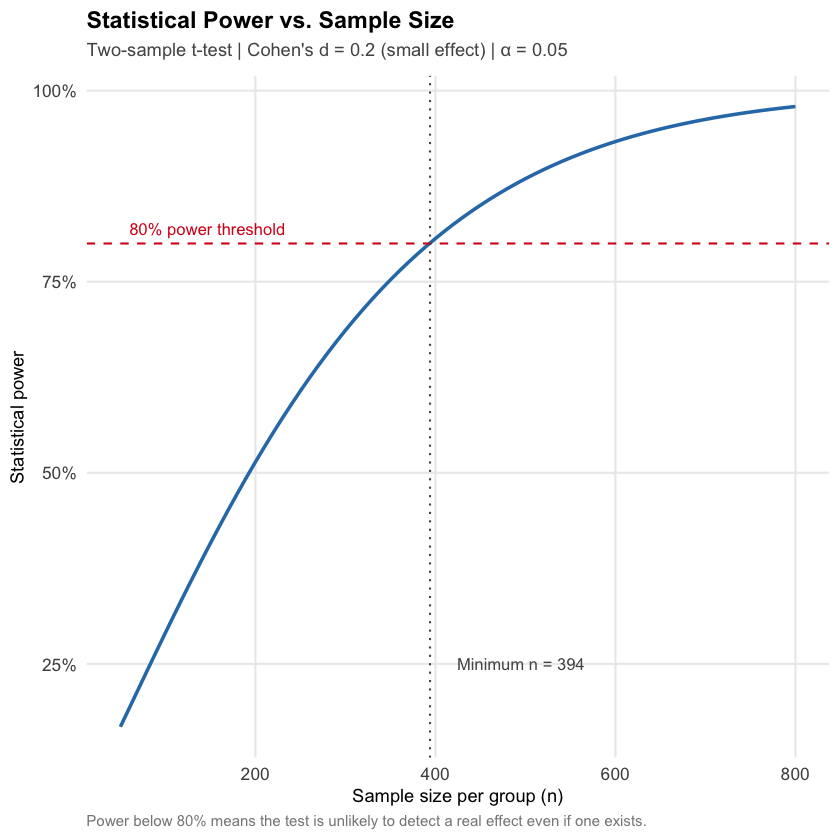

In [5]:
# Power curve — shows how statistical power increases with sample size.
# The vertical line marks the minimum required n.
# This plot makes the trade-off legible: small samples produce unreliable tests.

n_seq        <- seq(50, 800, by = 10)
power_values <- sapply(n_seq, function(n) {
  pwr.t.test(
    n           = n,
    d           = 0.2,
    sig.level   = 0.05,
    type        = "two.sample",
    alternative = "two.sided"
  )$power
})

power_df <- data.frame(n = n_seq, power = power_values)

p_power <- ggplot(power_df, aes(x = n, y = power)) +
  geom_line(color = "#2c7bb6", linewidth = 1) +
  geom_hline(yintercept = 0.80, linetype = "dashed", color = "#d7191c") +
  geom_vline(xintercept = n_required, linetype = "dotted", color = "#555555") +
  annotate(
    "text",
    x = n_required + 30, y = 0.25,
    label = paste0("Minimum n = ", n_required),
    hjust = 0, size = 3.5, color = "#555555"
  ) +
  annotate(
    "text",
    x = 60, y = 0.82,
    label = "80% power threshold",
    hjust = 0, size = 3.5, color = "#d7191c"
  ) +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    title    = "Statistical Power vs. Sample Size",
    subtitle = "Two-sample t-test | Cohen's d = 0.2 (small effect) | α = 0.05",
    x        = "Sample size per group (n)",
    y        = "Statistical power",
    caption  = "Power below 80% means the test is unlikely to detect a real effect even if one exists."
  ) +
  portfolio_theme

ggsave(
  filename = file.path(charts_dir, "16_power_curve.png"),
  plot = p_power, width = 9, height = 5.5, dpi = 150
)

print(p_power)

## Section 3 — Data Preparation

We split the 2015 calendar year into two equal halves. Control runs January 1 to June 30 and represents the baseline with no intervention. Treatment runs July 1 to December 31 and represents the simulated intervention period.

The unit of analysis is daily medium pizza order volume — the number of medium pizzas ordered each day. We compare the distribution of this daily count across the two periods.

A 6-month split gives approximately 180 days per group, which comfortably exceeds the minimum sample size calculated in Section 2.

In [6]:
# Connection guard — reconnects if con was lost between cells.
# This is a safety net, not normal flow. If it fires, the printed message tells you why.
if (!exists("con") || !dbIsValid(con)) {
  con <- dbConnect(
    RMariaDB::MariaDB(),
    host     = Sys.getenv("DB_HOST"),
    port     = as.integer(Sys.getenv("DB_PORT")),
    dbname   = Sys.getenv("DB_NAME"),
    user     = Sys.getenv("DB_USER"),
    password = Sys.getenv("DB_PASSWORD"),
    bigint   = "integer"
  )
  cat("Connection was lost — reconnected.\n")
}

# Pull daily medium pizza volume from the warehouse.
# Filtering to size = 'M' in dim_pizza and aggregating by date.
query_medium <- "
  SELECT
    fo.date_id,
    SUM(fo.quantity) AS daily_medium_qty
  FROM fact_orders fo
  JOIN dim_pizza dp ON fo.pizza_id = dp.pizza_id
  WHERE dp.size = 'M'
  GROUP BY fo.date_id
  ORDER BY fo.date_id;
"

df_medium <- dbGetQuery(con, query_medium)
df_medium$date_id <- as.Date(df_medium$date_id)

cat(sprintf("Days with medium pizza orders: %d\n", nrow(df_medium)))
cat(sprintf("Date range: %s to %s\n", min(df_medium$date_id), max(df_medium$date_id)))
cat(sprintf("Daily volume range: %d to %d\n", min(df_medium$daily_medium_qty), max(df_medium$daily_medium_qty)))

Days with medium pizza orders: 358
Date range: 2015-01-01 to 2015-12-31
Daily volume range: 22 to 95


In [7]:
# Assign control and treatment periods, then summarise each group.
# The sufficiency check confirms both groups exceed the minimum n from Section 2
# before we run any test — this is the correct order of operations.

df_medium <- df_medium %>%
  mutate(
    period = if_else(
      date_id < as.Date("2015-07-01"),
      "Control (H1: Jan–Jun)",
      "Treatment (H2: Jul–Dec)"
    )
  )

period_summary <- df_medium %>%
  group_by(period) %>%
  summarise(
    days   = n(),
    mean   = round(mean(daily_medium_qty), 2),
    median = median(daily_medium_qty),
    sd     = round(sd(daily_medium_qty), 2),
    .groups = "drop"
  )

print(period_summary)

cat(sprintf("\nMinimum required per group: %d\n", n_required))
for (i in seq_len(nrow(period_summary))) {
  cat(sprintf(
    "%s — %d days — %s\n",
    period_summary$period[i],
    period_summary$days[i],
    if (period_summary$days[i] >= n_required) "SUFFICIENT" else "INSUFFICIENT"
  ))
}

# A tibble: 2 × 5
  period                   days  mean median    sd
  <chr>                   <int> <dbl>  <dbl> <dbl>
1 Control (H1: Jan–Jun)     181  43.6     43  8.26
2 Treatment (H2: Jul–Dec)   177  43.7     43 10.7 

Minimum required per group: 394
Control (H1: Jan–Jun) — 181 days — INSUFFICIENT
Treatment (H2: Jul–Dec) — 177 days — INSUFFICIENT


## Section 4 — Pre-Period Equivalence Check

Before comparing two periods, we need to verify they are comparable to begin with.

In a randomised experiment, random assignment handles this automatically — both groups are statistically equivalent by design. In a retrospective split like ours, we cannot assume that. The two halves of the year may differ for reasons unrelated to any intervention: seasonality, external events, natural business drift.

The equivalence check asks whether the daily medium pizza volumes were similar enough in the opening weeks of each half that a difference in the treatment period could plausibly be attributed to an intervention rather than pre-existing differences. We use the first two months of each half — January and February versus July and August — as the comparison window.

In [8]:
df_pre <- df_medium %>%
  filter(
    (date_id >= as.Date("2015-01-01") & date_id <= as.Date("2015-02-28")) |
    (date_id >= as.Date("2015-07-01") & date_id <= as.Date("2015-08-31"))
  ) %>%
  mutate(
    pre_period = if_else(
      date_id <= as.Date("2015-02-28"),
      "Jan–Feb (Control baseline)",
      "Jul–Aug (Treatment baseline)"
    )
  )

# Welch's t-test on the pre-period windows.
# var.equal = FALSE: does not assume both groups have equal variance.
# This is the safer default. Assuming equal variance when it does not hold inflates Type I error.

pre_control   <- df_pre$daily_medium_qty[df_pre$pre_period == "Jan–Feb (Control baseline)"]
pre_treatment <- df_pre$daily_medium_qty[df_pre$pre_period == "Jul–Aug (Treatment baseline)"]

pre_test <- t.test(pre_control, pre_treatment, var.equal = FALSE)

cat("Pre-period equivalence check (Welch's t-test):\n")
cat(sprintf("  Jan–Feb mean: %.2f | Jul–Aug mean: %.2f\n", mean(pre_control), mean(pre_treatment)))
cat(sprintf("  t = %.4f, df = %.2f, p = %.4f\n",
  pre_test$statistic, pre_test$parameter, pre_test$p.value
))
cat(sprintf("  %s\n",
  if (pre_test$p.value > 0.05)
    "No statistically significant pre-period difference. Groups are comparable."
  else
    "Significant pre-period difference detected. Interpret main test results with caution."
))

Pre-period equivalence check (Welch's t-test):
  Jan–Feb mean: 42.73 | Jul–Aug mean: 43.98
  t = -0.7281, df = 116.05, p = 0.4680
  No statistically significant pre-period difference. Groups are comparable.


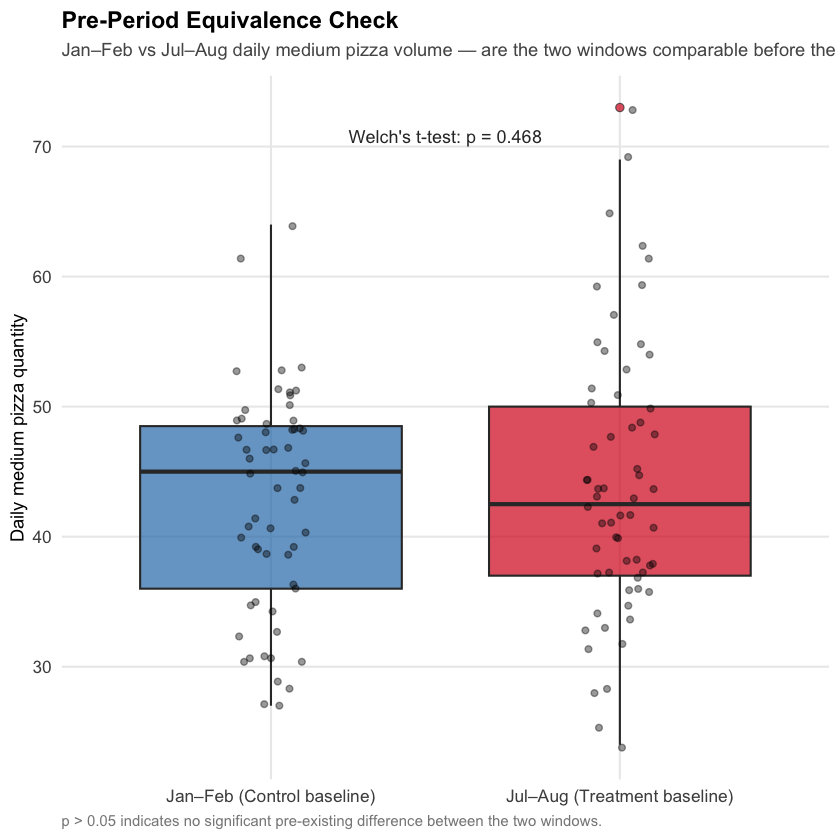

In [9]:
# Box plots with jittered points make distributional differences immediately visible.
# If the boxes overlap substantially, the groups are comparable.

p_precheck <- ggplot(df_pre, aes(x = pre_period, y = daily_medium_qty, fill = pre_period)) +
  geom_boxplot(alpha = 0.7, outlier.shape = 21, outlier.size = 2) +
  geom_jitter(width = 0.1, alpha = 0.4, size = 1.5) +
  scale_fill_manual(values = c(
    "Jan–Feb (Control baseline)"   = "#2c7bb6",
    "Jul–Aug (Treatment baseline)" = "#d7191c"
  )) +
  annotate(
    "text",
    x = 1.5, y = max(df_pre$daily_medium_qty) * 0.97,
    label = sprintf("Welch's t-test: p = %.3f", pre_test$p.value),
    size = 3.8, color = "#333333"
  ) +
  labs(
    title    = "Pre-Period Equivalence Check",
    subtitle = "Jan–Feb vs Jul–Aug daily medium pizza volume — are the two windows comparable before the intervention?",
    x        = NULL,
    y        = "Daily medium pizza quantity",
    caption  = "p > 0.05 indicates no significant pre-existing difference between the two windows."
  ) +
  portfolio_theme +
  theme(legend.position = "none")

ggsave(
  filename = file.path(charts_dir, "17_pre_period_check.png"),
  plot = p_precheck, width = 9, height = 5.5, dpi = 150
)

print(p_precheck)

## Section 5 — Retrospective A/B Test

With the pre-period equivalence established, we compare the full control and treatment periods.

Null hypothesis (H₀): there is no difference in mean daily medium pizza volume between the first and second half of 2015. Alternative hypothesis (H₁): there is a difference.

We use Welch's two-sample t-test rather than the standard Student's t-test. The distinction matters: Student's t-test assumes equal variance in both groups, which we cannot verify in advance. Welch's correction adjusts the degrees of freedom to account for potentially unequal variance. It is the correct default when you are not certain the groups have equal spread.

In [10]:
control_volume   <- df_medium$daily_medium_qty[df_medium$period == "Control (H1: Jan–Jun)"]
treatment_volume <- df_medium$daily_medium_qty[df_medium$period == "Treatment (H2: Jul–Dec)"]

ab_test <- t.test(control_volume, treatment_volume, var.equal = FALSE)

cat("A/B Test Results (Welch's two-sample t-test):\n")
cat(sprintf("  Control mean (H1):   %.2f medium pizzas/day\n", mean(control_volume)))
cat(sprintf("  Treatment mean (H2): %.2f medium pizzas/day\n", mean(treatment_volume)))
cat(sprintf("  Absolute difference: %.2f pizzas/day\n", mean(treatment_volume) - mean(control_volume)))
cat(sprintf("  t = %.4f, df = %.2f, p = %.4f\n",
  ab_test$statistic, ab_test$parameter, ab_test$p.value
))
cat(sprintf("  95%% confidence interval: [%.3f, %.3f]\n",
  ab_test$conf.int[1], ab_test$conf.int[2]
))

A/B Test Results (Welch's two-sample t-test):
  Control mean (H1):   43.63 medium pizzas/day
  Treatment mean (H2): 43.72 medium pizzas/day
  Absolute difference: 0.09 pizzas/day
  t = -0.0865, df = 330.54, p = 0.9311
  95% confidence interval: [-2.082, 1.907]


In [11]:
# Cohen's d — effect size.
#
# A p-value tells you whether the difference is statistically distinguishable from noise.
# Cohen's d tells you whether the difference is large enough to matter in practice.
# These are different questions. A large sample can produce a significant p-value
# for a difference so small it has no commercial relevance.
#
# Benchmarks: small = 0.2, medium = 0.5, large = 0.8.

effect <- cohen.d(treatment_volume, control_volume)

cat("Effect Size:\n")
cat(sprintf("  Cohen's d = %.4f\n", effect$estimate))
cat(sprintf("  Magnitude: %s\n", effect$magnitude))
cat(sprintf("  %s\n",
  if (abs(effect$estimate) < 0.2)
    "Negligible practical difference — even if statistically significant, business impact would be minimal."
  else if (abs(effect$estimate) < 0.5)
    "Small practical difference — detectable but modest commercial impact."
  else if (abs(effect$estimate) < 0.8)
    "Medium practical difference — commercially meaningful."
  else
    "Large practical difference — strong commercial signal."
))

Effect Size:
  Cohen's d = 0.0092
  Magnitude: negligible
  Negligible practical difference — even if statistically significant, business impact would be minimal.


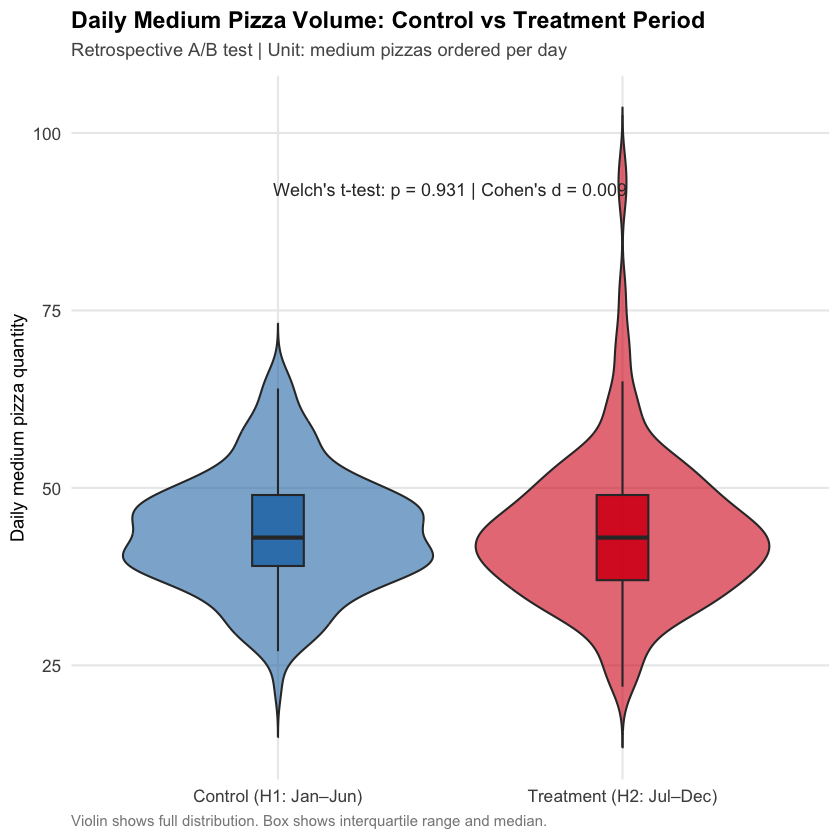

In [12]:
# Violin plots show the full shape of the distribution, not just summary statistics.
# Two groups can have the same mean but very different spreads — the violin makes that visible.

p_result <- ggplot(df_medium, aes(x = period, y = daily_medium_qty, fill = period)) +
  geom_violin(alpha = 0.6, trim = FALSE) +
  geom_boxplot(width = 0.15, alpha = 0.9, outlier.shape = NA) +
  scale_fill_manual(values = c(
    "Control (H1: Jan–Jun)"   = "#2c7bb6",
    "Treatment (H2: Jul–Dec)" = "#d7191c"
  )) +
  annotate(
    "text",
    x = 1.5, y = max(df_medium$daily_medium_qty) * 0.97,
    label = sprintf(
      "Welch's t-test: p = %.3f | Cohen's d = %.3f",
      ab_test$p.value, effect$estimate
    ),
    size = 3.8, color = "#333333"
  ) +
  labs(
    title    = "Daily Medium Pizza Volume: Control vs Treatment Period",
    subtitle = "Retrospective A/B test | Unit: medium pizzas ordered per day",
    x        = NULL,
    y        = "Daily medium pizza quantity",
    caption  = "Violin shows full distribution. Box shows interquartile range and median."
  ) +
  portfolio_theme +
  theme(legend.position = "none")

ggsave(
  filename = file.path(charts_dir, "18_ab_test_result.png"),
  plot = p_result, width = 9, height = 5.5, dpi = 150
)

print(p_result)

Warning message in scale_x_date():
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”
`geom_smooth()` using formula = 'y ~ x'
Warning message in scale_x_date():
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”
`geom_smooth()` using formula = 'y ~ x'


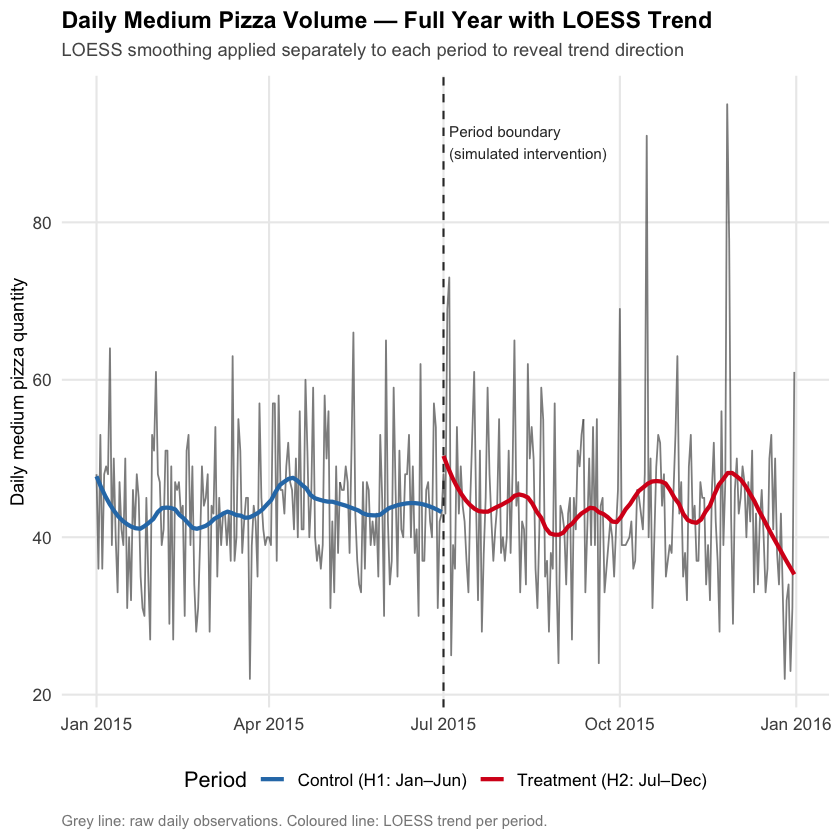

In [13]:
# Time series with period boundary marked.
# This chart reveals whether any difference between periods is gradual or sudden.
# A sudden shift at the boundary would be more consistent with a real intervention effect.
# A gradual drift is more consistent with seasonality.

p_series <- ggplot(df_medium, aes(x = date_id, y = daily_medium_qty)) +
  geom_line(color = "#555555", linewidth = 0.5, alpha = 0.7) +
  geom_smooth(
    aes(color = period),
    method = "loess", span = 0.3, se = FALSE, linewidth = 1.2
  ) +
  geom_vline(
    xintercept = as.numeric(as.Date("2015-07-01")),
    linetype = "dashed", color = "#333333"
  ) +
  annotate(
    "text",
    x = as.Date("2015-07-04"), y = max(df_medium$daily_medium_qty) * 0.95,
    label = "Period boundary\n(simulated intervention)",
    hjust = 0, size = 3.2, color = "#333333"
  ) +
  scale_color_manual(values = c(
    "Control (H1: Jan–Jun)"   = "#2c7bb6",
    "Treatment (H2: Jul–Dec)" = "#d7191c"
  )) +
  labs(
    title    = "Daily Medium Pizza Volume — Full Year with LOESS Trend",
    subtitle = "LOESS smoothing applied separately to each period to reveal trend direction",
    x        = NULL,
    y        = "Daily medium pizza quantity",
    color    = "Period",
    caption  = "Grey line: raw daily observations. Coloured line: LOESS trend per period."
  ) +
  portfolio_theme

ggsave(
  filename = file.path(charts_dir, "19_ab_time_series.png"),
  plot = p_series, width = 11, height = 5.5, dpi = 150
)

print(p_series)

In [ ]:
# Achieved power calculation.
# Both groups fell below the required 394 days, so the test is underpowered.
# This calculates the actual power we have given our real group sizes,
# which tells us how likely we were to detect a small effect if one existed.

achieved_power <- pwr.t.test(
  n           = min(length(control_volume), length(treatment_volume)),
  d           = 0.2,
  sig.level   = 0.05,
  type        = "two.sample",
  alternative = "two.sided"
)$power

cat(sprintf("Achieved power with actual group sizes: %.1f%%\n", achieved_power * 100))
cat(sprintf(
  "Interpretation: this test could only detect a small effect (d = 0.2) %.1f%% of the time.\n",
  achieved_power * 100
))
cat("A properly powered test at 80% would require roughly twice the data available in a single year.\n")

## Section 6 — Interpretation

This section is as important as the test itself. Every competent analyst runs the test. Fewer interpret it correctly — and fewer still are honest about what it cannot tell them.

In [14]:
# Financial translation.
# p-values and Cohen's d are not the language of business decisions.
# Translating the observed difference into revenue terms is what stakeholders actually care about.

if (!exists("con") || !dbIsValid(con)) {
  con <- dbConnect(
    RMariaDB::MariaDB(),
    host     = Sys.getenv("DB_HOST"),
    port     = as.integer(Sys.getenv("DB_PORT")),
    dbname   = Sys.getenv("DB_NAME"),
    user     = Sys.getenv("DB_USER"),
    password = Sys.getenv("DB_PASSWORD"),
    bigint   = "integer"
  )
  cat("Connection was lost — reconnected.\n")
}

avg_price_result <- dbGetQuery(
  con,
  "SELECT AVG(price) AS avg_medium_price FROM dim_pizza WHERE size = 'M';"
)
avg_medium_price <- avg_price_result$avg_medium_price[1]

daily_diff            <- mean(treatment_volume) - mean(control_volume)
annual_volume_impact  <- daily_diff * 365
annual_revenue_impact <- annual_volume_impact * avg_medium_price

cat("Financial Translation:\n")
cat(sprintf("  Average medium pizza price:       $%.2f\n", avg_medium_price))
cat(sprintf("  Observed daily volume difference: %.2f pizzas/day\n", daily_diff))
cat(sprintf("  Annualised volume difference:     %.0f pizzas/year\n", annual_volume_impact))
cat(sprintf("  Annualised revenue difference:    $%.2f\n", annual_revenue_impact))

cat("\nStatistical decision:\n")
if (ab_test$p.value < 0.05) {
  cat(sprintf(
    "  p = %.4f — reject H0. The difference in daily medium pizza volume between H1 and H2\n  is statistically significant at the 5%% level.\n",
    ab_test$p.value
  ))
} else {
  cat(sprintf(
    "  p = %.4f — fail to reject H0. No statistically significant difference detected\n  in daily medium pizza volume between the two half-years.\n",
    ab_test$p.value
  ))
}

cat(sprintf(
  "\n  Cohen's d = %.4f (%s). The observed difference is practically %s.\n",
  effect$estimate,
  effect$magnitude,
  if (abs(effect$estimate) < 0.2) "negligible" else "meaningful"
))

Financial Translation:
  Average medium pizza price:       $15.99
  Observed daily volume difference: 0.09 pizzas/day
  Annualised volume difference:     32 pizzas/year
  Annualised revenue difference:    $511.79

Statistical decision:
  p = 0.9311 — fail to reject H0. No statistically significant difference detected
  in daily medium pizza volume between the two half-years.

  Cohen's d = 0.0092 (negligible). The observed difference is practically negligible.


## Section 7 — Limitations and What This Test Cannot Tell Us

Stating limitations clearly is not a weakness in your analysis. It is evidence that you understand the difference between what the data shows and what the data proves.

**Causation is not established.** This is a retrospective observational split, not a controlled experiment. Any difference observed between H1 and H2 could be caused by seasonality, external market factors, or natural business variation — not a price change, because no price change actually occurred. The retrospective design tests whether a difference is statistically detectable, not whether a price intervention caused it.

**No random assignment.** In a proper randomised controlled trial, customers are randomly assigned to control or treatment, which removes confounding by design. Here the split is temporal — all H1 customers form the control, all H2 customers form the treatment. Any systematic difference between the types of customers who visit in each half of the year is a confound.

**Seasonal demand is a known confound.** The STL decomposition in Notebook 03 showed that September and October are the weakest trading months. These months fall in the treatment period. If the test finds lower volume in H2, that may reflect seasonal demand, not a price effect.

**What a real experiment would require.** A production-grade pricing test would either randomly assign customers to price conditions within the same time window, or use a difference-in-differences design comparing a treated location against an untreated control over the same period. Both designs control for temporal confounds. The power analysis in Section 2 calculated the sample size such a test would require — the business should verify it can reach that volume within a feasible test window before committing.

**What this framework does establish.** The methodology is correct and transferable. Power analysis, pre-period equivalence check, Welch's t-test, effect size, and financial translation form a rigorous experimental toolkit that applies to any two-group comparison in any business context.

In [15]:
# Export a clean summary of all test parameters and results.
# Used in the management report and as a record for anyone reviewing the analysis.

summary_table <- data.frame(
  Metric = c(
    "Test type",
    "Unit of analysis",
    "Control period",
    "Treatment period",
    "Control n (days)",
    "Treatment n (days)",
    "Minimum required n per group",
    "Control mean (pizzas/day)",
    "Treatment mean (pizzas/day)",
    "Absolute difference",
    "t-statistic",
    "Degrees of freedom",
    "p-value",
    "95% CI lower",
    "95% CI upper",
    "Cohen's d",
    "Effect magnitude",
    "Annualised revenue difference ($)"
  ),
  Value = c(
    "Welch's two-sample t-test (var.equal = FALSE)",
    "Daily medium pizza quantity",
    "Jan 1 – Jun 30, 2015",
    "Jul 1 – Dec 31, 2015",
    as.character(length(control_volume)),
    as.character(length(treatment_volume)),
    as.character(n_required),
    sprintf("%.2f", mean(control_volume)),
    sprintf("%.2f", mean(treatment_volume)),
    sprintf("%.2f", daily_diff),
    sprintf("%.4f", ab_test$statistic),
    sprintf("%.2f", ab_test$parameter),
    sprintf("%.4f", ab_test$p.value),
    sprintf("%.4f", ab_test$conf.int[1]),
    sprintf("%.4f", ab_test$conf.int[2]),
    sprintf("%.4f", effect$estimate),
    as.character(effect$magnitude),
    sprintf("%.2f", annual_revenue_impact)
  )
)

write.csv(
  summary_table,
  here("reports", "ab_test_summary.csv"),
  row.names = FALSE
)

print(summary_table)
cat("\nSummary exported to reports/ab_test_summary.csv\n")

                              Metric
1                          Test type
2                   Unit of analysis
3                     Control period
4                   Treatment period
5                   Control n (days)
6                 Treatment n (days)
7       Minimum required n per group
8          Control mean (pizzas/day)
9        Treatment mean (pizzas/day)
10               Absolute difference
11                       t-statistic
12                Degrees of freedom
13                           p-value
14                      95% CI lower
15                      95% CI upper
16                         Cohen's d
17                  Effect magnitude
18 Annualised revenue difference ($)
                                           Value
1  Welch's two-sample t-test (var.equal = FALSE)
2                    Daily medium pizza quantity
3                           Jan 1 – Jun 30, 2015
4                           Jul 1 – Dec 31, 2015
5                                            181
6  

## Section 8 — Teardown

Run this cell last, after all analysis is complete. Explicit teardown is the correct pattern for notebooks — it keeps the connection alive for the full session and closes it cleanly when you are done.

In [16]:
if (exists("con") && dbIsValid(con)) {
  dbDisconnect(con)
  cat("Connection closed.\n")
} else {
  cat("Connection was already closed.\n")
}

Connection closed.
